# ReBRAC C1 — Epoch Sensitivity Ablation

> **前置条件**：先跑 [rebrac_c1_train_convergence_check.ipynb](rebrac_c1_train_convergence_check.ipynb)。如 verdict = `H1 失败 (plateau)` → 不要跑本 notebook，去跑 asym critic。

## 假设（用户提出）

> upstream 难度高，64 epochs 可能没收敛。

## 测试设计

**single seed × 256 epochs（4× current budget）+ 周期 eval + 周期 checkpoint**：

| 维度 | reward ablation | **本 notebook** |
|---|---|---|
| epochs | 64 | **256** |
| seeds | 42, 44 (2) | **42 only (1)** — 节省 EV |
| dataset | arr_v2_s | **arr_v2_s（复用）** |
| critic | sym | **sym** |
| eval-every | off | **16 epochs (≈16 768 steps)** — val 40-ep |
| checkpoint-every | 8 epochs | **16 epochs** — 16/32/.../256 |
| post-train test eval | 1 final | **{64, 128, 192, 256} × 100-ep** |

预算 ~1.5h L4：训练 ~1h（4× current），post-eval ~30 min（4 ckpts × 100 ep × 6 worker）。

## Verdict 逻辑

看 `success_rate(epoch)` 曲线和 epoch 64 的对比：

| 现象 | 解读 |
|---|---|
| epoch 256 success ≥ 0.4，且单调上升 | **H1 成立** — epochs 是主因；broad_validation upstream 应升 budget |
| epoch 256 success < 0.30 或仅在 64–256 区间内震荡 | **H1 失败** — epochs 不是主因；s0+upstream 是真正瓶颈 |
| 64–256 之间小幅持续上升但未过 0.30 | **混合** — epochs 部分有效但收益递减 |

## 1. 环境 sanity check

In [ ]:
!lscpu | head -10
print()
!nvidia-smi

Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Address sizes:                           46 bits physical, 48 bits virtual
Byte Order:                              Little Endian
CPU(s):                                  12
On-line CPU(s) list:                     0-11
Vendor ID:                               GenuineIntel
Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz
CPU family:                              6
Model:                                   85

Wed May  6 11:46:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-U

In [ ]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

PyTorch: 2.10.0+cu128
CUDA available: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
%cd /content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5


## 2. 通用配置 — 复用 reward ablation 的 dataset / manifest

In [ ]:
import os
from pathlib import Path

# ---- dataset / 任务 / 评估配置（复用 reward ablation）----
OBJECTIVE = 'arrival_v2_simple'
PROBE_LAYOUT = 's0'
TASK_GEOMETRY = 'upstream'
TARGET_SPEED = 1.5
HISTORY_LENGTH = 4
FLOW_PATH = 'wake_data/wake_v8_U1p00_Re150_D12p00_dx0p60_Ti5pct_1200f_roi.npy'
BENCHMARK_KEY = 'single_u10_upstream_tgt15'
DATASET_EPISODES = 1000
VAL_EPISODES = 40
TEST_EPISODES = 100

# ---- 训练 anchor（仅 epochs 改）----
ACTOR_PENALTY_COEF = 4.0
CRITIC_PENALTY_COEF = 2.0
TRAIN_SEED = 42  # single seed for cost
TRAIN_EPOCHS = 256  # 4× original
BATCH_SIZE = 256
HIDDEN_DIM = 256
NUM_HIDDEN_LAYERS = 3
GAMMA = 0.99
TAU = 0.005
ACTOR_LR = 3e-4
CRITIC_LR = 3e-4
POLICY_NOISE = 0.2
NOISE_CLIP = 0.5
POLICY_FREQ = 2
GRAD_CLIP_NORM = 10.0
NORMALIZER_EPS = 1e-3

# ---- 周期 eval / checkpoint 频率（与 train_offline._steps_per_epoch ceil 一致）----
import math
DATASET_TRANSITIONS = 268_329
STEPS_PER_EPOCH = math.ceil(DATASET_TRANSITIONS / BATCH_SIZE)  # 1049
EPOCH_EVAL_INTERVAL = 16  # eval val every 16 epochs
EVAL_EVERY_STEPS = STEPS_PER_EPOCH * EPOCH_EVAL_INTERVAL  # 16 784
CHECKPOINT_EVERY_STEPS = STEPS_PER_EPOCH * EPOCH_EVAL_INTERVAL  # same cadence

# ---- 路径 ----
DATASET_NAME = (
    f'crosscomp_{PROBE_LAYOUT}_h{HISTORY_LENGTH}_{OBJECTIVE}'
    f'_re150_u10upstream_fixdone_ep{DATASET_EPISODES}'
)
DATASET_DIR = Path('offline_data') / DATASET_NAME
TRANSITIONS_NPZ = str(DATASET_DIR / 'transitions.npz')

CHECKPOINT_ROOT = Path('checkpoints/offline/rebrac/c1_epoch_sensitivity')
RESULTS_ROOT = Path('results/offline/rebrac/c1_epoch_sensitivity')

VAL_MANIFEST_PATH  = Path(f'benchmarks/c1_reward_ablation/val_{VAL_EPISODES}/{BENCHMARK_KEY}.json')
TEST_MANIFEST_PATH = Path(f'benchmarks/c1_reward_ablation/test_{TEST_EPISODES}/{BENCHMARK_KEY}.json')
VAL_MANIFEST_STR  = str(VAL_MANIFEST_PATH)
TEST_MANIFEST_STR = str(TEST_MANIFEST_PATH)

PAIR_TAG = f'actorb_{ACTOR_PENALTY_COEF:.1f}__criticb_{CRITIC_PENALTY_COEF:.1f}'.replace('.', 'p')
RUN_DIR = CHECKPOINT_ROOT / DATASET_NAME / PAIR_TAG / f'seed_{TRAIN_SEED}_e{TRAIN_EPOCHS}'
RUN_DIR_STR = str(RUN_DIR)

print(f'DATASET           = {DATASET_DIR}')
print(f'VAL_MANIFEST      = {VAL_MANIFEST_PATH}  (exists={VAL_MANIFEST_PATH.exists()})')
print(f'TEST_MANIFEST     = {TEST_MANIFEST_PATH}  (exists={TEST_MANIFEST_PATH.exists()})')
print(f'RUN_DIR           = {RUN_DIR}')
print(f'STEPS_PER_EPOCH   = {STEPS_PER_EPOCH}')
print(f'TOTAL_STEPS       = {STEPS_PER_EPOCH * TRAIN_EPOCHS:,}')
print(f'EVAL_EVERY_STEPS  = {EVAL_EVERY_STEPS:,}  (every {EPOCH_EVAL_INTERVAL} epochs)')
print(f'CHECKPOINT_EVERY_STEPS = {CHECKPOINT_EVERY_STEPS:,}')

DATASET           = offline_data/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000
VAL_MANIFEST      = benchmarks/c1_reward_ablation/val_40/single_u10_upstream_tgt15.json  (exists=True)
TEST_MANIFEST     = benchmarks/c1_reward_ablation/test_100/single_u10_upstream_tgt15.json  (exists=True)
RUN_DIR           = checkpoints/offline/rebrac/c1_epoch_sensitivity/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/actorb_4p0__criticb_2p0/seed_42_e256
STEPS_PER_EPOCH   = 1049
TOTAL_STEPS       = 268,544
EVAL_EVERY_STEPS  = 16,784  (every 16 epochs)
CHECKPOINT_EVERY_STEPS = 16,784


## 3. 训练 — single seed × 256 epochs + 周期 eval + 周期 checkpoint

训练时每 16 epochs 在 val_40 manifest 上做一次 eval（写到 `eval_log.csv`），并保存 checkpoint。这给我们「训练中 success vs epoch」曲线。

In [ ]:
if (RUN_DIR / 'agent_final.pt').exists():
    print(f'[skip] training done: {RUN_DIR}')
else:
    print(f'\n========== train seed {TRAIN_SEED} × {TRAIN_EPOCHS} epochs → {RUN_DIR} ==========')
    !python -m scripts.train_offline \
        --algo rebrac \
        --offline-data {TRANSITIONS_NPZ} \
        --flow {FLOW_PATH} \
        --manifest {VAL_MANIFEST_STR} \
        --probe-layout {PROBE_LAYOUT} \
        --history-length {HISTORY_LENGTH} \
        --task-geometry {TASK_GEOMETRY} \
        --target-speed {TARGET_SPEED} \
        --objective {OBJECTIVE} \
        --sampling-mode shuffle_no_replacement \
        --num-epochs {TRAIN_EPOCHS} \
        --batch-size {BATCH_SIZE} \
        --hidden-dim {HIDDEN_DIM} \
        --num-hidden-layers {NUM_HIDDEN_LAYERS} \
        --gamma {GAMMA} \
        --tau {TAU} \
        --actor-lr {ACTOR_LR} \
        --critic-lr {CRITIC_LR} \
        --actor-penalty-coef {ACTOR_PENALTY_COEF} \
        --critic-penalty-coef {CRITIC_PENALTY_COEF} \
        --policy-noise {POLICY_NOISE} \
        --noise-clip {NOISE_CLIP} \
        --policy-freq {POLICY_FREQ} \
        --grad-clip-norm {GRAD_CLIP_NORM} \
        --normalizer-eps {NORMALIZER_EPS} \
        --eval-every {EVAL_EVERY_STEPS} \
        --eval-episodes {VAL_EPISODES} \
        --eval-workers 6 \
        --eval-worker-device cpu \
        --checkpoint-every {CHECKPOINT_EVERY_STEPS} \
        --skip-final-eval \
        --seed {TRAIN_SEED} \
        --device cuda \
        --save-dir {RUN_DIR_STR}


========== train seed 42 × 256 epochs → checkpoints/offline/rebrac/c1_epoch_sensitivity/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/actorb_4p0__criticb_2p0/seed_42_e256 ==========
[offline] algo=rebrac transitions=268329 obs_dim=40 action_dim=2 protocol=deployable tensor_replay=on eval_workers=6 sampling=shuffle_no_replacement total_steps=268544
[train] step=1 epoch=1 epoch_step=1 q=-0.927 critic=165.002 actor=5.655 bc=1.164 lambda=1.079 critic_pen=1.244
[train] step=1000 epoch=1 epoch_step=1000 q=-2.731 critic=138.105 actor=0.916 bc=0.037 lambda=0.281 critic_pen=0.086
[train] step=2000 epoch=2 epoch_step=951 q=-2.266 critic=2.313 actor=0.576 bc=0.027 lambda=0.207 critic_pen=0.078
[train] step=3000 epoch=3 epoch_step=902 q=-1.005 critic=152.565 actor=0.245 bc=0.022 lambda=0.155 critic_pen=0.093
[train] step=4000 epoch=4 epoch_step=853 q=-1.350 critic=3.116 actor=0.316 bc=0.029 lambda=0.147 critic_pen=0.090
[train] step=5000 epoch=5 epoch_step=804 q=0.590 critic=

## 4. 训练中 val curve — success_rate vs epoch (40-ep val)

这是 `eval_log.csv` 的现成产物，无需额外 GPU。

[eval_log.csv]
 train_step  reward_objective  eval_return  eval_safety_cost  eval_success_rate  eval_time_s  eval_energy  eval_path_length_m  eval_progress_ratio  eval_path_efficiency    epoch
      16784 arrival_v2_simple    -160.8338           20.8702             0.1000     210.0475  133131.5289            110.2761               0.3181                0.2642  16.0000
      33568 arrival_v2_simple    -135.1362           15.7750             0.1250     210.8700  132080.1426            107.5821               0.3654                0.2973  32.0000
      50352 arrival_v2_simple    -133.5153           16.4712             0.1250     210.5600  130744.2868            106.0771               0.3976                0.3147  48.0000
      67136 arrival_v2_simple    -132.6405           15.6709             0.1250     211.3950  130391.4556            105.1881               0.4114                0.3240  64.0000
      83920 arrival_v2_simple    -134.0575           16.0132             0.1250     211.9300  1

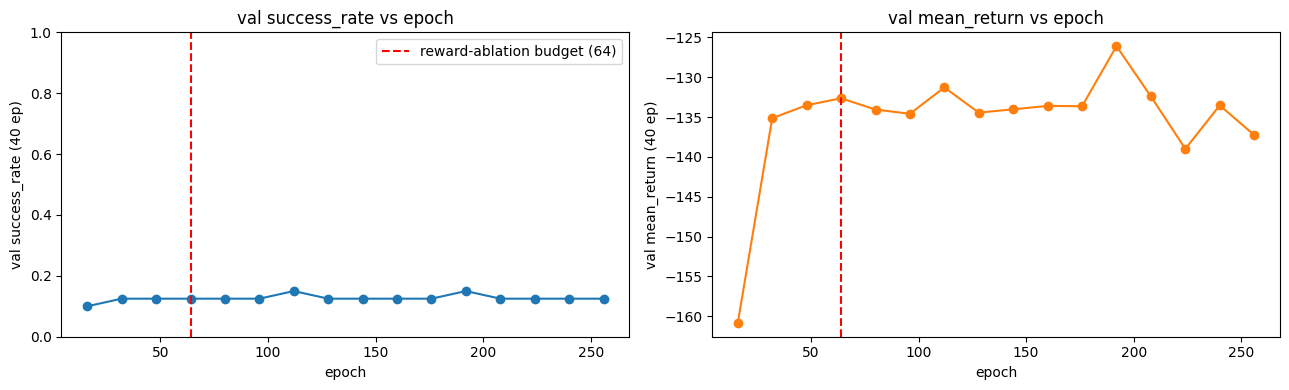

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

eval_log_path = RUN_DIR / 'eval_log.csv'
if not eval_log_path.exists():
    print(f'[warn] missing: {eval_log_path}')
    val_df = pd.DataFrame()
else:
    val_df = pd.read_csv(eval_log_path)
    step_col = 'train_step' if 'train_step' in val_df.columns else 'step'
    val_df['epoch'] = val_df[step_col] / STEPS_PER_EPOCH
    print('[eval_log.csv]')
    print(val_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

if not val_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(val_df['epoch'], val_df['eval_success_rate'], marker='o')
    axes[0].axvline(64, color='red', linestyle='--', label='reward-ablation budget (64)')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('val success_rate (40 ep)')
    axes[0].set_title('val success_rate vs epoch')
    axes[0].set_ylim(0, 1)
    axes[0].legend()
    axes[1].plot(val_df['epoch'], val_df['eval_return'], marker='o', color='C1')
    axes[1].axvline(64, color='red', linestyle='--')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('val mean_return (40 ep)')
    axes[1].set_title('val mean_return vs epoch')
    plt.tight_layout()
    plt.show()

## 5. Post-train test eval — {64, 128, 192, 256} epochs on 100-ep test manifest

Val 用的是 40-ep 噪声较大；test 用 100-ep + fixed manifest 给最终 verdict 数字。

In [ ]:
import json

TEST_DIR = RESULTS_ROOT / DATASET_NAME / PAIR_TAG / f'seed_{TRAIN_SEED}_e{TRAIN_EPOCHS}' / 'test'
TEST_DIR.mkdir(parents=True, exist_ok=True)

TEST_EPOCHS = [64, 128, 192, 256]

# Map epoch → checkpoint file
# train_offline saves periodic checkpoints as agent_step_<step>.pt
checkpoint_map = {}
for e in TEST_EPOCHS:
    step = STEPS_PER_EPOCH * e
    if e == TRAIN_EPOCHS:
        ckpt = RUN_DIR / 'agent_final.pt'
    else:
        # train_offline filenames: agent_step_<step>.pt (zero-padded? checked)
        candidates = sorted(RUN_DIR.glob('agent_step_*.pt'))
        target_step_str = str(step)
        ckpt = None
        for c in candidates:
            # name like agent_step_0016768.pt or agent_step_16768.pt
            stem = c.stem.replace('agent_step_', '').lstrip('0') or '0'
            if stem == target_step_str:
                ckpt = c
                break
        if ckpt is None:
            # fallback: closest by absolute distance to target_step
            def _step_of(path: Path) -> int:
                stem = path.stem.replace('agent_step_', '')
                try:
                    return int(stem)
                except ValueError:
                    return -1
            steps_avail = [(_step_of(c), c) for c in candidates if _step_of(c) > 0]
            if steps_avail:
                ckpt = min(steps_avail, key=lambda kv: abs(kv[0] - step))[1]
    checkpoint_map[e] = ckpt

for e, c in checkpoint_map.items():
    exists = c is not None and c.exists()
    print(f'epoch {e:>4d}: {c}  exists={exists}')

epoch   64: checkpoints/offline/rebrac/c1_epoch_sensitivity/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/actorb_4p0__criticb_2p0/seed_42_e256/agent_step_00067136.pt  exists=True
epoch  128: checkpoints/offline/rebrac/c1_epoch_sensitivity/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/actorb_4p0__criticb_2p0/seed_42_e256/agent_step_00134272.pt  exists=True
epoch  192: checkpoints/offline/rebrac/c1_epoch_sensitivity/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/actorb_4p0__criticb_2p0/seed_42_e256/agent_step_00201408.pt  exists=True
epoch  256: checkpoints/offline/rebrac/c1_epoch_sensitivity/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/actorb_4p0__criticb_2p0/seed_42_e256/agent_final.pt  exists=True


In [ ]:
for epoch in TEST_EPOCHS:
    out_path = TEST_DIR / f'epoch_{epoch}.json'
    out_path_str = str(out_path)
    if out_path.exists():
        print(f'[skip] eval done: {out_path}')
        continue
    ckpt = checkpoint_map.get(epoch)
    if ckpt is None or not ckpt.exists():
        print(f'[warn] missing checkpoint for epoch {epoch}')
        continue
    # evaluate_offline expects a checkpoint dir or trainer_state.json path
    # for periodic checkpoints we need to point it at the file directly via --agent-file
    if ckpt.name == 'agent_final.pt':
        ckpt_arg = RUN_DIR_STR
        agent_file_arg_block = ''
    else:
        ckpt_arg = RUN_DIR_STR
        agent_file_arg_block = f' --agent-file {ckpt.name}'
    print(f'\n========== eval epoch {epoch} ({ckpt.name}) → {out_path} ==========')
    !python -m scripts.evaluate_offline \
        --checkpoint {ckpt_arg}{agent_file_arg_block} \
        --manifest {TEST_MANIFEST_STR} \
        --episodes {TEST_EPISODES} \
        --num-workers 6 \
        --worker-device cpu \
        --device cuda \
        --output-json {out_path_str}


========== eval epoch 64 (agent_step_00067136.pt) → results/offline/rebrac/c1_epoch_sensitivity/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/actorb_4p0__criticb_2p0/seed_42_e256/test/epoch_64.json ==========
reward_objective      : arrival_v2_simple
energy_cost_gain      : 0.000000
safety_cost_gain      : 0.500000
episodes              : 100
success_rate          : 20.0%
avg_return            : -102.25 +/- 157.14
avg_safety_cost       : 25.748 +/- 39.507
avg_time_s            : 203.73 +/- 49.45
avg_time_s_success    : 127.76
avg_energy            : 125844.25 +/- 30276.17
avg_path_length_m     : 99.29 +/- 29.43
avg_progress_ratio    : 0.471 +/- 0.398
avg_path_efficiency   : 0.383 +/- 0.328
termination           : {'timeout': 54, 'out_of_bounds': 26, 'goal': 20}
benchmark_manifest    : benchmarks/c1_reward_ablation/test_100/single_u10_upstream_tgt15.json

========== eval epoch 128 (agent_step_00134272.pt) → results/offline/rebrac/c1_epoch_sensitivity/crosscomp_s0_h

## 6. Test success_rate vs epoch — final curve

[post-train test — success vs epoch]
 epoch  success_rate  mean_return  goal_pct  timeout_pct  oob_pct
    64        0.2000    -102.2518    0.2000       0.5400   0.2600
   128        0.2000    -106.3469    0.2000       0.5200   0.2800
   192        0.2200     -96.1565    0.2200       0.5200   0.2600
   256        0.2200     -96.1565    0.2200       0.5200   0.2600


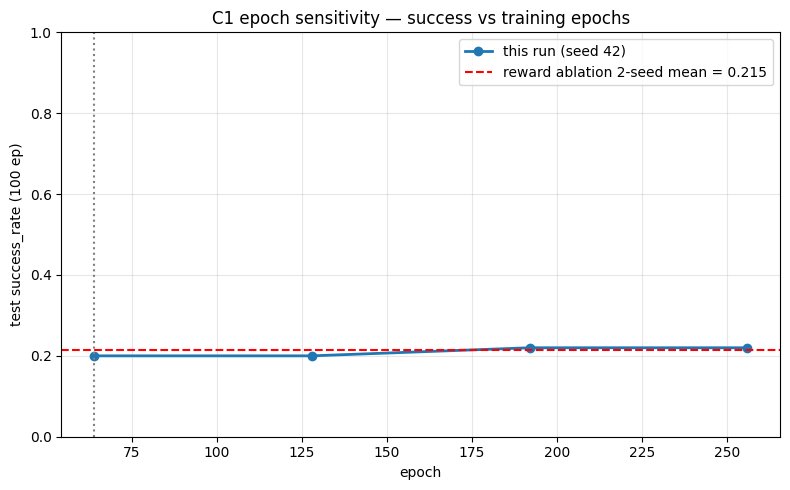

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for epoch in TEST_EPOCHS:
    p = TEST_DIR / f'epoch_{epoch}.json'
    if not p.exists():
        print(f'[warn] missing: {p}')
        continue
    d = json.loads(p.read_text(encoding='utf-8'))
    term = d.get('eval_termination_counts', {})
    n = max(int(d.get('eval_episodes', 100)), 1)
    rows.append({
        'epoch':        epoch,
        'success_rate': d['eval_success_rate'],
        'mean_return':  d['eval_return'],
        'goal_pct':     term.get('goal', 0)         / n,
        'timeout_pct':  term.get('timeout', 0)      / n,
        'oob_pct':      term.get('out_of_bounds', 0) / n,
    })
test_df = pd.DataFrame(rows)
print('[post-train test — success vs epoch]')
print(test_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

if not test_df.empty:
    REWARD_ABL_2SEED_SUCCESS = 0.215
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(test_df['epoch'], test_df['success_rate'], marker='o', linewidth=2, label='this run (seed 42)')
    ax.axhline(REWARD_ABL_2SEED_SUCCESS, color='red', linestyle='--',
               label=f'reward ablation 2-seed mean = {REWARD_ABL_2SEED_SUCCESS:.3f}')
    ax.axvline(64, color='gray', linestyle=':')
    ax.set_xlabel('epoch')
    ax.set_ylabel('test success_rate (100 ep)')
    ax.set_title('C1 epoch sensitivity — success vs training epochs')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7. Verdict — H1 (epochs 不够) 是否成立？

| 现象 | verdict | next step |
|---|---|---|
| epoch 256 success ≥ 0.40 且单调上升 | **H1 成立** | broad_validation upstream 升 budget；其他 upstream spokes 重训 |
| 在 64–256 之间持续小幅上升但 < 0.40 | **混合** | 收益递减；asym critic 仍是更高优先级 |
| 64–256 内基本平 / 震荡 / 下降 | **H1 失败** | epochs 不是主因 → 跑 asym critic notebook |

In [ ]:
if test_df.empty or len(test_df) < 2:
    print('[abort] test data insufficient — cannot verdict')
else:
    succ_64  = float(test_df.loc[test_df['epoch'] == 64,  'success_rate'].mean()) if (test_df['epoch'] == 64 ).any() else float('nan')
    succ_256 = float(test_df.loc[test_df['epoch'] == 256, 'success_rate'].mean()) if (test_df['epoch'] == 256).any() else float('nan')
    delta_pp = (succ_256 - succ_64) * 100

    # monotonic check
    succ_series = test_df.sort_values('epoch')['success_rate'].values
    monotonic = all(b >= a - 0.02 for a, b in zip(succ_series, succ_series[1:]))

    print('=' * 72)
    print(f'C1 epoch sensitivity — verdict (single seed {TRAIN_SEED})')
    print('-' * 72)
    print(f'  success @ epoch 64  = {succ_64:.4f}')
    print(f'  success @ epoch 256 = {succ_256:.4f}')
    print(f'  Δ (256 − 64)        = {delta_pp:+.2f} pp')
    print(f'  monotonic ascent    = {monotonic}')
    print('-' * 72)

    if succ_256 >= 0.40 and monotonic:
        verdict = 'H1 成立：epochs 是 C1 失败的主因之一'
        next_step = (
            'Plan: (1) broad_validation 文档加 §「upstream epoch budget」；'
            '(2) C1 anchor 用 256 epochs 重做 5-seed；'
            '(3) 其他 upstream-flavored spokes (sbs_u15_upstream 等) 同样升 budget'
        )
    elif succ_256 >= 0.30 or (succ_256 - succ_64) > 0.05:
        verdict = '混合：epochs 部分有效但收益递减'
        next_step = (
            'Plan: (1) 先跑 asym critic（更高 EV）；'
            '(2) 若 asym 也有效，做 256 ep + asym 的联合 ablation；'
            '(3) 报告写「epochs 单独无法救 C1」'
        )
    else:
        verdict = 'H1 失败：epochs 不是 C1 失败主因'
        next_step = (
            'Plan: epochs 路径关闭。回到 asym critic notebook 继续验证 H2。'
            '若 asym 也无效，C1 重定义为 sensor floor spoke'
        )

    print(f'  verdict   : {verdict}')
    print(f'  next-step : {next_step}')
    print('=' * 72)

C1 epoch sensitivity — verdict (single seed 42)
------------------------------------------------------------------------
  success @ epoch 64  = 0.2000
  success @ epoch 256 = 0.2200
  Δ (256 − 64)        = +2.00 pp
  monotonic ascent    = True
------------------------------------------------------------------------
  verdict   : H1 失败：epochs 不是 C1 失败主因
  next-step : Plan: epochs 路径关闭。回到 asym critic notebook 继续验证 H2。若 asym 也无效，C1 重定义为 sensor floor spoke
